In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

df = pd.read_csv("../data/processed_paysim.csv")

X = df.drop(columns=["isFraud"])
y = df["isFraud"]

In [5]:
df_sample = df.sample(n=300_000, random_state=42)

X_s = df_sample.drop(columns=["isFraud"])
y_s = df_sample["isFraud"]

(300000, 14)


In [6]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.001,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_s)

iso_pred = iso.predict(X_s)

iso_pred = (iso_pred == -1).astype(int)

print("Isolation Forest ROC-AUC:", roc_auc_score(y_s, iso_pred))
print(classification_report(y_s, iso_pred)

Isolation Forest ROC-AUC: 0.5111123100653477
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    299612
           1       0.03      0.02      0.03       388

    accuracy                           1.00    300000
   macro avg       0.51      0.51      0.51    300000
weighted avg       1.00      1.00      1.00    300000



In [7]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.001
)

lof_pred = lof.fit_predict(X_s)
lof_pred = (lof_pred == -1).astype(int)

print("LOF ROC-AUC:", roc_auc_score(y_s, lof_pred))
print(classification_report(y_s, lof_pred))

LOF ROC-AUC: 0.5007896811147229
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    299612
           1       0.00      0.00      0.00       388

    accuracy                           1.00    300000
   macro avg       0.50      0.50      0.50    300000
weighted avg       1.00      1.00      1.00    300000



In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

0.0012907418642005967 0.0012911347840983745


In [9]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

scale_pos_weight: 773.7482496194825


In [15]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

In [ ]:
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

In [ ]:
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba > 0.9).astype(int)

print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print(classification_report(y_val, y_val_pred))

              feature  importance
1              amount          19
6   orig_balance_diff           9
0                step           8
2       oldbalanceOrg           8
4      oldbalanceDest           6
5      newbalanceDest           6
10      type_CASH_OUT           3
3      newbalanceOrig           2
12       type_PAYMENT           1
13      type_TRANSFER           1
7   dest_balance_diff           0
8   orig_zero_balance           0
9   dest_zero_balance           0
11         type_DEBIT           0


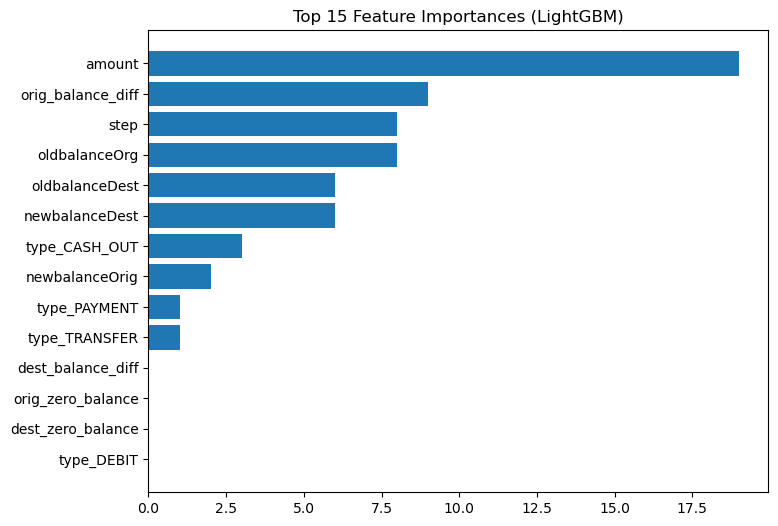

In [20]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X_train.columns

fi = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(fi.head(15))

plt.figure(figsize=(8, 6))
plt.barh(fi["feature"][:15][::-1], fi["importance"][:15][::-1])
plt.title("Top 15 Feature Importances (LightGBM)")
plt.show()

In [24]:
import joblib

joblib.dump(model, "finsheild_lgbm.pkl")

['finsheild_lgbm.pkl']